# Machine learning for cell segmentation

**Duration** ~50 min &nbsp;·&nbsp; **Session** Day 2, Python notebooks

**This notebook covers**

- loading and interpreting a Weka probability map
- what a *pixel* classifier fundamentally cannot do
- running Cellpose, and tuning its one important parameter

**Data**: `data/bbbc020/` and Weka segmentations in `data/bbbc020/weka/`.

## 1. Loading a Weka probability map in Python

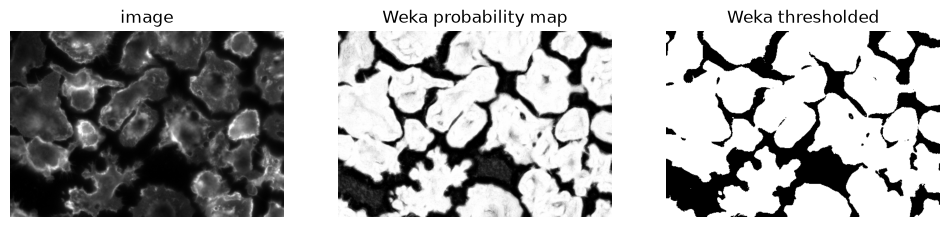

In [29]:
import numpy as np
import tifffile
import matplotlib.pyplot as plt

from skimage.measure import label
from skimage.color import label2rgb

from course import DATA, show

FIELD = "24h_2"

cells = tifffile.imread(DATA / "bbbc020" / "images" / f"{FIELD}_cells.tif")
truth = tifffile.imread(DATA / "bbbc020" / "gt" / f"{FIELD}_cells_labels.tif")

# If you exported your own in E4, point this at results/weka/ instead.
weka_dir = DATA / "bbbc020" / "weka"
probability = tifffile.imread(weka_dir / f"{FIELD}_cells_probability_2.tif")
binary_image = probability[1] > 0.3

fig, axes = plt.subplots(1, 3, figsize=(12, 3))

show(cells, ax=axes[0], title="image")
show(probability[1], ax=axes[1], title="Weka probability map")
show(binary_image, ax=axes[2], title="Weka thresholded")

### Can we use watershed to separate touching cells?

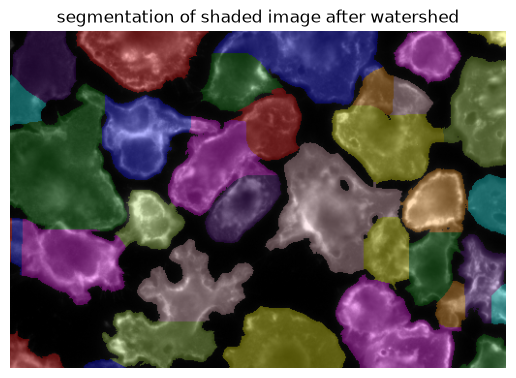

In [31]:
from scipy.ndimage import maximum_filter
from skimage.segmentation import watershed
from scipy.ndimage import distance_transform_edt
from skimage.filters import gaussian

def seeds_from_peaks(distance, mask):
    """Return a labeled array of seeds, one for each local maximum in `distance`."""

    # maximum filter: replace pixels with the maximum value in a neighborhood
    seeds = maximum_filter(distance, size=3)
    # Compare the maximum-filtered image with the original distance transform: only keep pixels that are equal to the maximum in their neighborhood.
    seeds = (seeds == distance)  # True where the pixel is a local maximum
    seeds = seeds * mask  # only keep seeds that are in the mask
    seeds = label(seeds)  # label the seeds so that each gets a unique integer

    return seeds

distance = distance_transform_edt(binary_image)
smoothed_distance = gaussian(distance, sigma=10.0)
seeds = seeds_from_peaks(smoothed_distance, binary_image)
w = watershed(-smoothed_distance, seeds, mask=binary_image)

show(label2rgb(w, bg_label=0, image=cells), title="segmentation of shaded image after watershed")

### How about using a nuclear segmentation as a seed for Watershed?

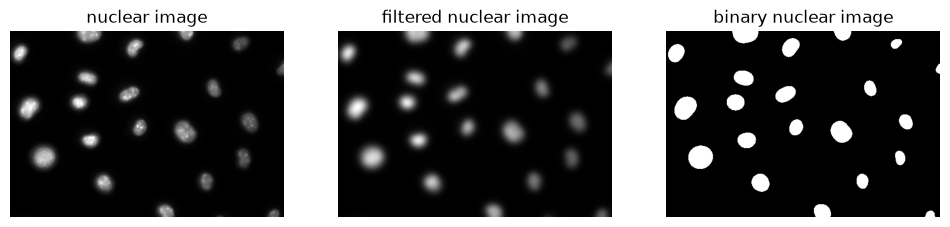

In [32]:
nuclei = tifffile.imread(DATA / "bbbc020" / "images" / f"{FIELD}_nuclei.tif")

from skimage.filters import threshold_otsu
# watershed on gaussian blurred nuclei image
filtered_nuclei = gaussian(nuclei, sigma=5.0)
t = threshold_otsu(filtered_nuclei)
binary_image_nuclei = filtered_nuclei > t

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
show(nuclei, title="nuclear image", ax=axes[0])
show(filtered_nuclei, title="filtered nuclear image", ax=axes[1])
show(binary_image_nuclei, title="binary nuclear image", ax=axes[2])


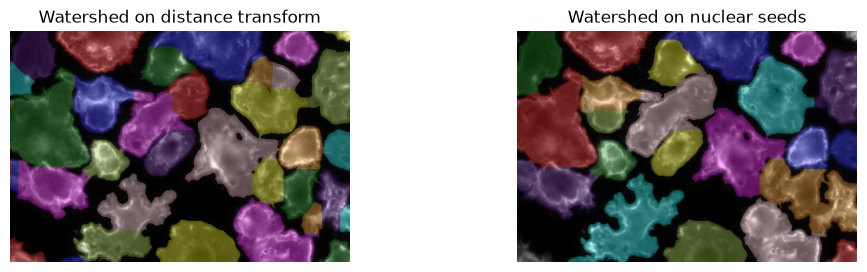

In [34]:
distance = distance_transform_edt(binary_image)
smoothed_distance = gaussian(distance, sigma=10.0)
seeds = label(binary_image_nuclei)  # use the nuclei as seeds
watershed_nuclear_seeds = watershed(-smoothed_distance, seeds, mask=binary_image)

fig, axs = plt.subplots(1, 2, figsize=(12, 3))
show(label2rgb(w, bg_label=0, image=cells), title="Watershed on distance transform", ax=axs[0])
show(label2rgb(watershed_nuclear_seeds, bg_label=0, image=cells), title="Watershed on nuclear seeds", ax=axs[1])

Watershed on nuclear is a good way to combine the two types of complementary informations:
- the foreground / background cell segmentation
- cell identity based on the nuclear segmentation

## 3. Cellpose

[Cellpose](https://www.cellpose.org) is a deep model trained on a large, varied
collection of cell images. Two things make it practical here:

1. **It outputs instances**, not a pixel mask: touching cells come out separated.
2. **It generalises.** It runs below on images it has never seen, with no
   additional training.

In [62]:
from cellpose import models

# `cyto` is the general cell model; there is also a `nuclei` model.
model = models.Cellpose(model_type="cyto3", gpu=False)

In [63]:
# diameter=None asks Cellpose to estimate object size itself.
masks, flows, styles, diameter = model.eval(cells, diameter=None, channels=[0, 0])

print(f"estimated diameter : {diameter:.0f} px")
print(f"objects found      : {masks.max()}")
print(f"annotated          : {truth.max()}")

estimated diameter : 62 px
objects found      : 26
annotated          : 23


### Inspecting the Cellpose output

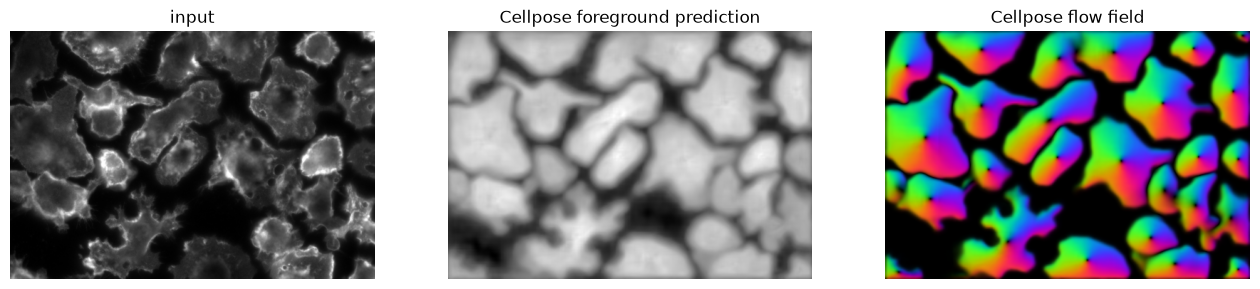

In [64]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
show(cells, title="input", ax=axes[0])
show(flows[2], title="Cellpose foreground prediction", ax=axes[1])
show(flows[0], title="Cellpose flow field", ax=axes[2])

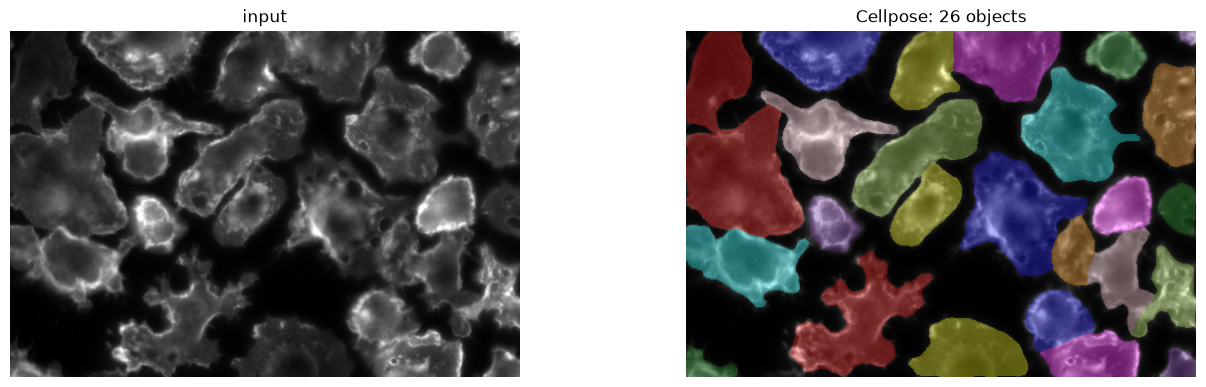

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
show(cells, title="input", ax=axes[0])
show(label2rgb(masks, bg_label=0, image=cells), title=f"Cellpose: {masks.max()} objects", ax=axes[1])

### Cellpose with both channels (nuclei + cytoplasm)

In [66]:
# Combine the two images into one multichannel image
img = np.stack([cells, nuclei], axis=-1)

# Segment cells using both channels
masks, flows, styles, diameter = model.eval(
    img,
    diameter=None,
    channels=[1, 2],
    channel_axis=-1
)

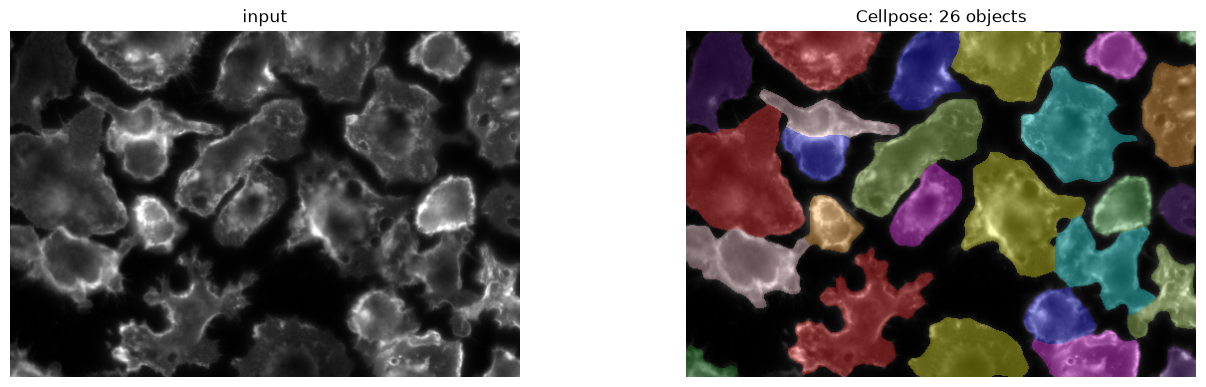

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
show(cells, title="input", ax=axes[0])
show(label2rgb(masks, bg_label=0, image=cells), title=f"Cellpose: {masks.max()} objects", ax=axes[1])

## Recap

| | Training | Output | Separates touching objects |
|---|---|---|---|
| threshold | None | pixels | no |
| Weka | Manual scribbles | Semantic segmentation / pixel classes | no |
| Pixel classifier + Watershed | Depends on the classifier | Instance segmentation / objects | yes |
| Cellpose | Large ground truth dataset | Instance segmentation / objects | yes |

For cells, Cellpose generally performs very well. However, for non-cell like objects which it has not been trained on, a pixel classifier might be a better choice.